## TMP

In [87]:
%pip install -U catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.2/97.2 MB 7.2 MB/s eta 0:00:0000:0100:01m
  Attempting uninstall: catboost
    Found existing installation: catboost 1.2.8
    Uninstalling catboost-1.2.8:
      Successfully uninstalled catboost-1.2.8
Note: you may need to restart the kernel to use updated packages.


In [97]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm
import time
import pandas as pd

import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score
import xgboost as xgb
import catboost as cb
import lightgbm as lgb

In [98]:
test_table = pd.read_csv("./data_raw/clean_table.csv", index_col=0)

/tmp/ipykernel_130640/3834989859.py:1: DtypeWarning: Columns (34,35,41) have mixed types. Specify dtype option on import or set low_memory=False.
  test_table = pd.read_csv("./data_raw/clean_table.csv", index_col=0)


In [ ]:
test_table["Name"] = test_table["Name"].astype("str")

In [56]:
test_table

,Код пациента,Name,Age,Sex,STEMI,ЧКВ,Вид STEMI,Инфаркт-зависимая артерия,Поражение ствола,Количество пораженных сосудов(Syntax),...,PCO2VenMax (b),ScvO2Min (b),ScvO2Max (b),LactVenMin (b),LactVenMax (b),BEVenMin (b),BEVenMax (b),HCO3VenMin (b),HCO3VenMax (b),BNP (b)
47,17-12105,Бабаев СН,59.0,М,Нет,Да,NaN,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,17-17180,Ползиков СВ,58.0,М,Нет,Да,NaN,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,15536,Анфёров ЮА,74.0,М,Нет,Да,NaN,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
461,21-8249,Арутюнян МА,66.0,NaN,Нет,Да,NaN,ПМЖВ - Несовадает,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,17-20825,Кондрашин АА,31.0,М,Нет,Нет,NaN,0,Нет,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,19-9921,Шишов ГД,71.0,М,Да,Да,Задний,ПКА,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6505,19-9912,Рой АГ,63.0,М,Да,Да,Задний,ПКА,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6506,19-99,Красулин НТ,64.0,М,Да,Да,Передний,ПМЖВ,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6485,19-1267,Сасов КП,70.0,М,Нет,Да,NaN,2,Да,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
test_table["Смерть"] = test_table["Смерть"].map({"Да": 1, "Нет": 0})
test_table.dropna(subset=["Смерть"], inplace=True)

------------

In [22]:
scorers = {
    "pr_auc": "average_precision",  # Главная метрика при дисбалансе
    "roc_auc": "roc_auc",  # Дополнительная (может завышаться)
    "f1": make_scorer(f1_score, pos_label=1),
    "bal_acc": make_scorer(balanced_accuracy_score),
}


In [6]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

In [ ]:
test_table["Смерть"] = test_table["Смерть"].map({"Да": 1, "Нет": 0})
test_table.dropna(subset=["Смерть"], inplace=True)

X = test_table.drop(["Смерть"], axis=1)
y = test_table["Смерть"]


def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace("[", "_").replace("]", "_").replace("<", "_lt_")
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace(">", "_gt_").replace(" ", "_").replace(":", "_")
        clean_col = clean_col.replace("(", "_").replace(")", "_").replace(",", "_")
        clean_col = clean_col.replace("{", "_").replace("}", "_").replace("|", "_")
        # Удаляем последовательные подчеркивания
        clean_col = "_".join(filter(None, clean_col.split("_")))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip("_")
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = "f_" + clean_col
        new_columns.append(clean_col)

    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean


# Применяем к вашим данным
X_clean = clean_column_names(X)

object_cols = X_clean.select_dtypes(include=["object"]).columns

from sklearn.preprocessing import LabelEncoder

for col in object_cols:
    le = LabelEncoder()
    # Обучаем encoder на объединённых данных, чтобы избежать ошибок с новыми категориями в тесте
    combined = pd.concat([X_clean[col], X_clean[col]], axis=0).astype(str)
    le.fit(combined)
    X_clean[col] = le.transform(X_clean[col].astype(str))

X_clean.drop(["Код_пациента"], axis=1, inplace=True)

In [24]:
scale_pos_weight = len(y[y == 0]) / max(1, len(y[y == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

In [18]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
        # missing=np.nan,  # явно указываем, что NaN - это пропуски
        random_state=42,
        eval_metric="logloss",  # для бинарной классификации
        tree_method="auto",  # автоматический выбор метода обучения
        enable_categorical=True,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        class_weight=class_weight_dict,  # борьба с дисбалансом
        random_state=42,
        verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    ),
    "CatBoost": CatBoostClassifier(
        iterations=100,
        depth=5,
        learning_rate=0.1,
        class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
        random_state=42,
        verbose=False,
        eval_metric="Logloss",
    ),
}

In [19]:
results = {}
for name, model in models.items():
    print(f"\n🔄 CV для {name}...")
    cv_res = cross_validate(
        model,
        X_clean,
        y,
        cv=cv,
        scoring=scorers,
        n_jobs=-1,
        return_train_score=False,  # n_jobs=1 безопаснее для бустингов
    )
    results[name] = cv_res


🔄 CV для XGBoost...

🔄 CV для LightGBM...

🔄 CV для CatBoost...


AttributeError: The following error was raised: 'CatBoostClassifier' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.

In [20]:
print("\n" + "=" * 80)
print("📈 Честные метрики (Repeated Stratified 5-Fold CV, 10 повторов = 50 оценок)")
print("=" * 80)
print(f"{'Model':<12} | {'PR-AUC':<18} | {'ROC-AUC':<18} | {'F1':<18} | {'Bal Acc':<18}")
print("-" * 80)


def fmt_ci(scores):
    m = np.mean(scores)
    ci_l, ci_h = np.percentile(scores, [2.5, 97.5])
    return f"{m:.3f} [{ci_l:.3f}–{ci_h:.3f}]"


for name, res in results.items():
    print(
        f"{name:<12} | {fmt_ci(res['test_pr_auc']):<18} | {fmt_ci(res['test_roc_auc']):<18} | "
        f"{fmt_ci(res['test_f1']):<18} | {fmt_ci(res['test_bal_acc']):<18}"
    )


📈 Честные метрики (Repeated Stratified 5-Fold CV, 10 повторов = 50 оценок)
Model        | PR-AUC             | ROC-AUC            | F1                 | Bal Acc           
--------------------------------------------------------------------------------
XGBoost      | 0.700 [0.617–0.757] | 0.958 [0.934–0.972] | 0.593 [0.547–0.642] | 0.858 [0.818–0.899]
LightGBM     | 0.702 [0.631–0.760] | 0.958 [0.937–0.973] | 0.595 [0.547–0.640] | 0.858 [0.818–0.896]


-------------

### Another CV

In [59]:
X_clean

,Name,Age,Sex,STEMI,ЧКВ,Вид_STEMI,Инфаркт-зависимая_артерия,Поражение_ствола,Количество_пораженных_сосудов_Syntax,Количество_пораженных_сосудов_Значимость,...,PCO2VenMax_b,ScvO2Min_b,ScvO2Max_b,LactVenMin_b,LactVenMax_b,BEVenMin_b,BEVenMax_b,HCO3VenMin_b,HCO3VenMax_b,BNP_b
47,533,59.0,2,2,1,0,1,2,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,9476,58.0,2,2,1,0,1,2,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,384,74.0,2,2,1,0,15,2,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,5568,31.0,2,2,2,0,0,2,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
687,7642,43.0,0,2,1,0,19,2,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,13532,71.0,2,1,1,1,16,2,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6505,10130,63.0,2,1,1,1,16,2,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6506,6030,64.0,2,1,1,2,18,2,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6485,10534,70.0,2,2,1,0,1,1,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
X_cv = X_clean.drop(columns=["Name", "Код пациента"], errors="ignore").copy()
y_cv = y.copy()

In [61]:
groups = X_clean["Name"].astype(str).str.strip().str.upper()

In [62]:
groups

47         533
106       9476
158        384
568       5568
687       7642
         ...  
6503     13532
6505     10130
6506      6030
6485     10534
17429     9159
Name: Name, Length: 16613, dtype: object

In [ ]:
scorers = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": make_scorer(f1_score, pos_label=1),
    "bal_acc": make_scorer(balanced_accuracy_score),
}

In [65]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [66]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
        # missing=np.nan,  # явно указываем, что NaN - это пропуски
        random_state=42,
        eval_metric="logloss",  # для бинарной классификации
        tree_method="auto",  # автоматический выбор метода обучения
        enable_categorical=True,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        class_weight=class_weight_dict,  # борьба с дисбалансом
        random_state=42,
        verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    ),
    "CatBoost": CatBoostClassifier(
        iterations=100,
        depth=5,
        learning_rate=0.1,
        class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
        random_state=42,
        verbose=False,
        eval_metric="Logloss",
    ),
}

In [ ]:
results = {}
for name, model in models.items():
    print(f"\n🔄 StratifiedGroupCV для {name}...")
    cv_res = cross_validate(
        model,
        X_cv,
        y_cv,
        cv=sgkf,
        groups=groups,  # ← Ключевой параметр
        scoring=scorers,
        n_jobs=-1,
        return_train_score=False,
    )
    results[name] = cv_res


🔄 StratifiedGroupCV для XGBoost...

🔄 StratifiedGroupCV для LightGBM...

🔄 StratifiedGroupCV для CatBoost...


AttributeError: The following error was raised: 'CatBoostClassifier' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.

In [ ]:
# 6. Вывод с 95% ДИ
print("\n" + "=" * 80)
print("📈 Метрики (StratifiedGroupKFold, группировка по Name, 5 фолдов)")
print("=" * 80)
print(f"{'Model':<12} | {'PR-AUC':<18} | {'ROC-AUC':<18} | {'F1':<18} | {'Bal Acc':<18}")
print("-" * 80)


def fmt_ci(scores):
    m = np.mean(scores)
    ci_l, ci_h = np.percentile(scores, [2.5, 97.5])
    return f"{m:.3f} [{ci_l:.3f}–{ci_h:.3f}]"


for mdl, res in results.items():
    print(
        f"{mdl:<12} | {fmt_ci(res['test_pr_auc']):<18} | {fmt_ci(res['test_roc_auc']):<18} | "
        f"{fmt_ci(res['test_f1']):<18} | {fmt_ci(res['test_bal_acc']):<18}"
    )


📈 Метрики (StratifiedGroupKFold, группировка по Name, 5 фолдов)
Model        | PR-AUC             | ROC-AUC            | F1                 | Bal Acc           
--------------------------------------------------------------------------------
XGBoost      | 0.690 [0.650–0.720] | 0.955 [0.947–0.965] | 0.578 [0.545–0.616] | 0.847 [0.823–0.869]
LightGBM     | 0.690 [0.642–0.717] | 0.954 [0.944–0.965] | 0.586 [0.539–0.626] | 0.858 [0.824–0.871]


In [70]:
sum(y), len(X_clean) - sum(y)

(575.0, 16038.0)

------------

### With hyperparameters

In [71]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=100,
        min_child_weight=15,
        subsample=0.8745297951606058,
        colsample_bytree=0.4954110056842209,
        gamma=5.233186685488018,
        reg_alpha=0.0005757915861725465,
        reg_lambda=4.198614550306633,
        max_depth=74,
        learning_rate=0.3705492544881076,
        scale_pos_weight=24.40033721777531,  # борьба с дисбалансом
        # missing=np.nan,  # явно указываем, что NaN - это пропуски
        random_state=42,
        eval_metric="logloss",  # для бинарной классификации
        tree_method="auto",  # автоматический выбор метода обучения
        enable_categorical=True,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        num_leaves=220,
        learning_rate=0.30906593527878456,
        min_child_samples=69,
        subsample=0.8701085058859857,
        colsample_bytree=0.4868258750883674,
        reg_alpha=0.023127138648795138,
        reg_lambda=0.06691267437317566,
        min_split_gain=0.1116982770332515,
        max_depth=8,
        class_weight=class_weight_dict,  # борьба с дисбалансом
        random_state=42,
        verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    ),
}

In [ ]:
results = {}
for name, model in models.items():
    print(f"\n🔄 StratifiedGroupCV для {name}...")
    cv_res = cross_validate(
        model,
        X_cv,
        y_cv,
        cv=sgkf,
        groups=groups,  # ← Ключевой параметр
        scoring=scorers,
        n_jobs=-1,
        return_train_score=False,
    )
    results[name] = cv_res


🔄 StratifiedGroupCV для XGBoost...

🔄 StratifiedGroupCV для LightGBM...


In [ ]:
# 6. Вывод с 95% ДИ
print("\n" + "=" * 80)
print("📈 Метрики (StratifiedGroupKFold, группировка по Name, 5 фолдов)")
print("=" * 80)
print(f"{'Model':<12} | {'PR-AUC':<18} | {'ROC-AUC':<18} | {'F1':<18} | {'Bal Acc':<18}")
print("-" * 80)


def fmt_ci(scores):
    m = np.mean(scores)
    ci_l, ci_h = np.percentile(scores, [2.5, 97.5])
    return f"{m:.3f} [{ci_l:.3f}–{ci_h:.3f}]"


for mdl, res in results.items():
    print(
        f"{mdl:<12} | {fmt_ci(res['test_pr_auc']):<18} | {fmt_ci(res['test_roc_auc']):<18} | "
        f"{fmt_ci(res['test_f1']):<18} | {fmt_ci(res['test_bal_acc']):<18}"
    )


📈 Метрики (StratifiedGroupKFold, группировка по Name, 5 фолдов)
Model        | PR-AUC             | ROC-AUC            | F1                 | Bal Acc           
--------------------------------------------------------------------------------
XGBoost      | 0.689 [0.670–0.716] | 0.957 [0.951–0.963] | 0.615 [0.574–0.643] | 0.830 [0.790–0.847]
LightGBM     | 0.716 [0.683–0.752] | 0.955 [0.941–0.966] | 0.654 [0.608–0.684] | 0.802 [0.775–0.820]


---------

### Stemi YES Hyperparameters NO

In [75]:
test_table = test_table[test_table["STEMI"] == "Да"]

In [ ]:
test_table.drop("STEMI", axis=1, inplace=True)

In [78]:
test_table["Смерть"] = test_table["Смерть"].map({"Да": 1, "Нет": 0})
test_table.dropna(subset=["Смерть"], inplace=True)

X = test_table.drop(["Смерть"], axis=1)
y = test_table["Смерть"]


def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace("[", "_").replace("]", "_").replace("<", "_lt_")
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace(">", "_gt_").replace(" ", "_").replace(":", "_")
        clean_col = clean_col.replace("(", "_").replace(")", "_").replace(",", "_")
        clean_col = clean_col.replace("{", "_").replace("}", "_").replace("|", "_")
        # Удаляем последовательные подчеркивания
        clean_col = "_".join(filter(None, clean_col.split("_")))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip("_")
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = "f_" + clean_col
        new_columns.append(clean_col)

    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean


# Применяем к вашим данным
X_clean = clean_column_names(X)

object_cols = X_clean.select_dtypes(include=["object"]).columns

from sklearn.preprocessing import LabelEncoder

for col in object_cols:
    le = LabelEncoder()
    # Обучаем encoder на объединённых данных, чтобы избежать ошибок с новыми категориями в тесте
    combined = pd.concat([X_clean[col], X_clean[col]], axis=0).astype(str)
    le.fit(combined)
    X_clean[col] = le.transform(X_clean[col].astype(str))

X_clean.drop(["Код_пациента"], axis=1, inplace=True)

In [80]:
X_cv = X_clean.drop(columns=["Name", "Код пациента"], errors="ignore").copy()
y_cv = y.copy()

In [81]:
groups = X_clean["Name"].astype(str).str.strip().str.upper()

In [93]:
scorers = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": make_scorer(f1_score, pos_label=1),
    "bal_acc": make_scorer(balanced_accuracy_score),
}

In [89]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [94]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
        # missing=np.nan,  # явно указываем, что NaN - это пропуски
        random_state=42,
        eval_metric="logloss",  # для бинарной классификации
        tree_method="auto",  # автоматический выбор метода обучения
        enable_categorical=True,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        class_weight=class_weight_dict,  # борьба с дисбалансом
        random_state=42,
        verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    ),
    "CatBoost": CatBoostClassifier(
        iterations=100,
        depth=5,
        learning_rate=0.1,
        class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
        random_state=42,
        verbose=False,
        eval_metric="Logloss",
    ),
}

In [95]:
results = {}
for name, model in models.items():
    print(f"\n🔄 StratifiedGroupCV для {name}...")
    cv_res = cross_validate(
        model,
        X_cv,
        y_cv,
        cv=sgkf,
        groups=groups,  # ← Ключевой параметр
        scoring=scorers,
        n_jobs=-1,
        return_train_score=False,
    )
    results[name] = cv_res


🔄 StratifiedGroupCV для XGBoost...

🔄 StratifiedGroupCV для LightGBM...

🔄 StratifiedGroupCV для CatBoost...


AttributeError: The following error was raised: 'CatBoostClassifier' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.

In [96]:
# 6. Вывод с 95% ДИ
print("\n" + "=" * 80)
print("📈 Метрики (StratifiedGroupKFold, группировка по Name, 5 фолдов)")
print("=" * 80)
print(f"{'Model':<12} | {'PR-AUC':<18} | {'ROC-AUC':<18} | {'F1':<18} | {'Bal Acc':<18}")
print("-" * 80)


def fmt_ci(scores):
    m = np.mean(scores)
    ci_l, ci_h = np.percentile(scores, [2.5, 97.5])
    return f"{m:.3f} [{ci_l:.3f}–{ci_h:.3f}]"


for mdl, res in results.items():
    print(
        f"{mdl:<12} | {fmt_ci(res['test_pr_auc']):<18} | {fmt_ci(res['test_roc_auc']):<18} | "
        f"{fmt_ci(res['test_f1']):<18} | {fmt_ci(res['test_bal_acc']):<18}"
    )


📈 Метрики (StratifiedGroupKFold, группировка по Name, 5 фолдов)
Model        | PR-AUC             | ROC-AUC            | F1                 | Bal Acc           
--------------------------------------------------------------------------------
XGBoost      | 0.848 [0.807–0.868] | 0.969 [0.962–0.974] | 0.756 [0.710–0.804] | 0.878 [0.861–0.899]
LightGBM     | 0.841 [0.797–0.858] | 0.968 [0.962–0.971] | 0.748 [0.710–0.793] | 0.875 [0.856–0.890]


-----------------

### STEMI YES HYPERPARAMETERS YES

In [99]:
test_table = test_table[test_table["STEMI"] == "Да"]

In [100]:
test_table.drop("STEMI", axis=1, inplace=True)

In [101]:
test_table["Смерть"] = test_table["Смерть"].map({"Да": 1, "Нет": 0})
test_table.dropna(subset=["Смерть"], inplace=True)

X = test_table.drop(["Смерть"], axis=1)
y = test_table["Смерть"]


def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace("[", "_").replace("]", "_").replace("<", "_lt_")
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace(">", "_gt_").replace(" ", "_").replace(":", "_")
        clean_col = clean_col.replace("(", "_").replace(")", "_").replace(",", "_")
        clean_col = clean_col.replace("{", "_").replace("}", "_").replace("|", "_")
        # Удаляем последовательные подчеркивания
        clean_col = "_".join(filter(None, clean_col.split("_")))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip("_")
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = "f_" + clean_col
        new_columns.append(clean_col)

    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean


# Применяем к вашим данным
X_clean = clean_column_names(X)

object_cols = X_clean.select_dtypes(include=["object"]).columns

from sklearn.preprocessing import LabelEncoder

for col in object_cols:
    le = LabelEncoder()
    # Обучаем encoder на объединённых данных, чтобы избежать ошибок с новыми категориями в тесте
    combined = pd.concat([X_clean[col], X_clean[col]], axis=0).astype(str)
    le.fit(combined)
    X_clean[col] = le.transform(X_clean[col].astype(str))

X_clean.drop(["Код_пациента"], axis=1, inplace=True)

In [102]:
X_cv = X_clean.drop(columns=["Name", "Код пациента"], errors="ignore").copy()
y_cv = y.copy()

In [103]:
groups = X_clean["Name"].astype(str).str.strip().str.upper()

In [104]:
scorers = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": make_scorer(f1_score, pos_label=1),
    "bal_acc": make_scorer(balanced_accuracy_score),
}

In [105]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [106]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=100,
        min_child_weight=15,
        subsample=0.8745297951606058,
        colsample_bytree=0.4954110056842209,
        gamma=5.233186685488018,
        reg_alpha=0.0005757915861725465,
        reg_lambda=4.198614550306633,
        max_depth=74,
        learning_rate=0.3705492544881076,
        scale_pos_weight=24.40033721777531,  # борьба с дисбалансом
        missing=np.nan,  # явно указываем, что NaN - это пропуски
        random_state=42,
        eval_metric="logloss",  # для бинарной классификации
        tree_method="auto",  # автоматический выбор метода обучения
        enable_categorical=True,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        num_leaves=220,
        learning_rate=0.30906593527878456,
        min_child_samples=69,
        subsample=0.8701085058859857,
        colsample_bytree=0.4868258750883674,
        reg_alpha=0.023127138648795138,
        reg_lambda=0.06691267437317566,
        min_split_gain=0.1116982770332515,
        max_depth=8,
        class_weight=class_weight_dict,  # борьба с дисбалансом
        random_state=42,
        verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    ),
}

In [107]:
results = {}
for name, model in models.items():
    print(f"\n🔄 StratifiedGroupCV для {name}...")
    cv_res = cross_validate(
        model,
        X_cv,
        y_cv,
        cv=sgkf,
        groups=groups,  # ← Ключевой параметр
        scoring=scorers,
        n_jobs=-1,
        return_train_score=False,
    )
    results[name] = cv_res


🔄 StratifiedGroupCV для XGBoost...

🔄 StratifiedGroupCV для LightGBM...


In [108]:
# 6. Вывод с 95% ДИ
print("\n" + "=" * 80)
print("📈 Метрики (StratifiedGroupKFold, группировка по Name, 5 фолдов)")
print("=" * 80)
print(f"{'Model':<12} | {'PR-AUC':<18} | {'ROC-AUC':<18} | {'F1':<18} | {'Bal Acc':<18}")
print("-" * 80)


def fmt_ci(scores):
    m = np.mean(scores)
    ci_l, ci_h = np.percentile(scores, [2.5, 97.5])
    return f"{m:.3f} [{ci_l:.3f}–{ci_h:.3f}]"


for mdl, res in results.items():
    print(
        f"{mdl:<12} | {fmt_ci(res['test_pr_auc']):<18} | {fmt_ci(res['test_roc_auc']):<18} | "
        f"{fmt_ci(res['test_f1']):<18} | {fmt_ci(res['test_bal_acc']):<18}"
    )


📈 Метрики (StratifiedGroupKFold, группировка по Name, 5 фолдов)
Model        | PR-AUC             | ROC-AUC            | F1                 | Bal Acc           
--------------------------------------------------------------------------------
XGBoost      | 0.811 [0.767–0.829] | 0.961 [0.955–0.966] | 0.714 [0.668–0.739] | 0.865 [0.834–0.890]
LightGBM     | 0.839 [0.813–0.851] | 0.966 [0.959–0.970] | 0.764 [0.738–0.791] | 0.849 [0.837–0.867]


-----------

In [ ]:
test_table["Смерть"]

47       0.0
106      0.0
158      0.0
568      0.0
687      0.0
        ... 
6503     0.0
6505     0.0
6506     0.0
6485     0.0
17429    0.0
Name: Смерть, Length: 16613, dtype: float64

In [ ]:
X = test_table.drop(["Смерть"], axis=1)
y = test_table["Смерть"]

In [ ]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace("[", "_").replace("]", "_").replace("<", "_lt_")
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace(">", "_gt_").replace(" ", "_").replace(":", "_")
        clean_col = clean_col.replace("(", "_").replace(")", "_").replace(",", "_")
        clean_col = clean_col.replace("{", "_").replace("}", "_").replace("|", "_")
        # Удаляем последовательные подчеркивания
        clean_col = "_".join(filter(None, clean_col.split("_")))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip("_")
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = "f_" + clean_col
        new_columns.append(clean_col)

    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean


# Применяем к вашим данным
X_clean = clean_column_names(X)

In [ ]:
object_cols = X_clean.select_dtypes(include=["object"]).columns

In [ ]:
X_clean

,Код_пациента,Name,Age,Sex,STEMI,ЧКВ,Вид_STEMI,Инфаркт-зависимая_артерия,Поражение_ствола,Количество_пораженных_сосудов_Syntax,...,PCO2VenMax_b,ScvO2Min_b,ScvO2Max_b,LactVenMin_b,LactVenMax_b,BEVenMin_b,BEVenMax_b,HCO3VenMin_b,HCO3VenMax_b,BNP_b
47,17-12105,Бабаев СН,59.0,М,Нет,Да,nan,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,17-17180,Ползиков СВ,58.0,М,Нет,Да,nan,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,15536,Анфёров ЮА,74.0,М,Нет,Да,nan,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,17-20825,Кондрашин АА,31.0,М,Нет,Нет,nan,0,Нет,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
687,14668,Мелещенко АВ,43.0,nan,Нет,Да,nan,ПМЖВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,19-9921,Шишов ГД,71.0,М,Да,Да,Задний,ПКА,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6505,19-9912,Рой АГ,63.0,М,Да,Да,Задний,ПКА,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6506,19-99,Красулин НТ,64.0,М,Да,Да,Передний,ПМЖВ,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6485,19-1267,Сасов КП,70.0,М,Нет,Да,nan,2,Да,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in object_cols:
    le = LabelEncoder()
    # Обучаем encoder на объединённых данных, чтобы избежать ошибок с новыми категориями в тесте
    combined = pd.concat([X_clean[col], X_clean[col]], axis=0).astype(str)
    le.fit(combined)
    X_clean[col] = le.transform(X_clean[col].astype(str))

In [ ]:
X_clean.drop(["Код_пациента"], axis=1, inplace=True)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# ШАГ 1: отделяем TEST (20% групп)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss1.split(X_clean, y, test_table["Name"]))

# Получаем индексы для train+val и test
X_train_val = X_clean.iloc[train_val_idx]
y_train_val = y.iloc[train_val_idx]
groups_train_val = test_table["Name"].iloc[train_val_idx]

# ШАГ 2: из оставшихся групп отделяем VALIDATION
# Доля валидации от ОСТАВШИХСЯ данных: val_frac = val_size / (train_size+val_size)
# Допустим, мы хотим train=0.6, val=0.2, test=0.2 от исходного датасета.
# Тогда val_frac = 0.2 / (0.6+0.2) = 0.25
val_frac = 0.25  # 25% от train_val
gss2 = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=42)
train_idx, val_idx = next(gss2.split(X_train_val, y_train_val, groups_train_val))

# Теперь train_idx, val_idx, test_idx – это индексы внутри ИСХОДНОГО датафрейма?
# Нет, нужно быть внимательным: gss2 вернул индексы относительно X_train_val, а не исходного df.
# Чтобы получить окончательные индексы в исходном df, делаем так:
train_idx_original = train_val_idx[train_idx]
val_idx_original = train_val_idx[val_idx]

# Теперь можно сформировать финальные выборки
X_train = X_clean.iloc[train_idx_original]
X_val = X_clean.iloc[val_idx_original]
X_test = X_clean.iloc[test_idx]

y_train = y.iloc[train_idx_original]
y_val = y.iloc[val_idx_original]
y_test = y.iloc[test_idx]

# Проверяем, что группы не пересекаются
print("Пациенты в train:", set(test_table.iloc[train_idx_original]["Name"]))
print("Пациенты в val:  ", set(test_table.iloc[val_idx_original]["Name"]))
print("Пациенты в test: ", set(test_table.iloc[test_idx]["Name"]))

Пациенты в train: {'Кудрин АА', 'Шаповалова ЕД', 'Ващенко НГ', 'Ожерельев АВ', 'Богачук ИВ', 'Жаботаев АС', 'Тяжова ТА', 'Белоцкий АВ', 'Голиков ПН', 'Больбат ДВ', 'Михайлова РН', 'Тимофеева ИЛ', 'Юмин АИ', 'Кубарев СН', 'Бондарев АЯ', 'Дудова ЗП', 'Балашов СВ', 'Иванов СМ', 'Лищинский БД', 'Ли СР', 'Кузнецова НА', 'Зайцев ВП', 'Королева ВА', 'Черней ЕВ', 'Завьялов ИС', 'Челпанов СЛ', 'Березина НП', 'Ершов ГА', 'Гаврилюк ИИ', 'Денисенко АА', 'Фисенко КО', 'Гитько АГ', 'Строзенко ВС', 'Лихобабина ЛА', 'Онуфриенко НА', 'Ковальчук ГИ', 'Марченко ОИ', 'Пантелеймонова ИЛ', 'Попова ТС', 'Носков ВВ', 'Пискунов ВТ', 'Дамаданов СМ', 'Ушаков АИ', 'Лютов ВЮ', 'Сергеев НМ', 'Виговская ЕН', 'Покотило ЕИ', 'Гринчук ЛИ', 'Мешков МИ', 'Гагаринская НИ', 'Лещева РН', 'Алексеенко ФС', 'Овчарук ОП', 'Огородникова СП', 'РОЖКОВГН ', 'Кизилова НВ', 'Верхозина СВ', 'Салий СА', 'Белов СН', 'Гуменюк ВН', 'Борисова ВЕ', 'Кан ОВ', 'Хлыстов АФ', 'Пинчук НН', 'Тарабанова НИ', 'Балов ВБ', 'Беленький АЮ', 'Шпунтенко 

In [ ]:
scale_pos_weight = len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

In [ ]:
import numpy as np
from IPython.display import display, Markdown
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    recall_score,
    precision_score,
)
import matplotlib.pyplot as plt

In [ ]:
def train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    """
    Обучает модель и оценивает её качество с фокусом на медицинские метрики
    Согласно официальной документации библиотек
    """
    start_time = time.time()

    display(Markdown(f"### 🚀 Обучение {model_name}..."))

    try:
        # Обучение модели в зависимости от типа (согласно документации)
        if model_name == "XGBoost":
            # Согласно документации XGBoost: https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        elif model_name == "LightGBM":
            # Согласно документации LightGBM: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
            model.fit(
                X_train,
                y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lightgbm.early_stopping(stopping_rounds=50, verbose=False)],  # Корректный синтаксис
            )

        elif model_name == "CatBoost":
            # Согласно документации CatBoost: https://catboost.ai/en/docs/concepts/python-quickstart
            model.fit(
                X_train,
                y_train,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                verbose=False,
                cat_features=cat_features,
            )

        train_time = time.time() - start_time
        display(Markdown(f"✅ **{model_name} обучена за {train_time:.2f} секунд**"))

        # Предсказания
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        y_pred_test = model.predict(X_test)

        # Вероятности для класса 1 (смерть)
        if hasattr(model, "predict_proba"):
            y_proba_train = model.predict_proba(X_train)[:, 1]
            y_proba_val = model.predict_proba(X_val)[:, 1]
            y_proba_test = model.predict_proba(X_test)[:, 1]
        else:
            # Для моделей без predict_proba
            y_proba_train = model.decision_function(X_train)
            y_proba_val = model.decision_function(X_val)
            y_proba_test = model.decision_function(X_test)

        # Оценка качества
        results = {}

        for dataset_name, y_true, y_pred, y_proba in [
            ("Train", y_train, y_pred_train, y_proba_train),
            ("Validation", y_val, y_pred_val, y_proba_val),
            ("Test", y_test, y_pred_test, y_proba_test),
        ]:
            # Основные метрики
            recall = recall_score(y_true, y_pred)  # Sensitivity - критично в медицине!
            precision = precision_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            roc_auc = roc_auc_score(y_true, y_proba)

            # Precision-Recall AUC (важнее ROC-AUC при дисбалансе)
            precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
            pr_auc = auc(recall_curve, precision_curve)

            results[dataset_name] = {
                "Recall (Sensitivity)": recall,
                "Precision": precision,
                "F1-score": f1,
                "ROC-AUC": roc_auc,
                "PR-AUC": pr_auc,
            }

        # Отображение результатов
        display(Markdown(f"### 📊 Результаты {model_name}:"))

        # Таблица метрик
        metrics_df = pd.DataFrame(results).T
        display(metrics_df.style.background_gradient(cmap="Blues", subset=["Recall (Sensitivity)", "PR-AUC"]))

        # Важно: анализ ошибок для медицины
        display(Markdown("### ⚠️ Анализ ошибок (крайне важно для медицины):"))

        # Confusion matrix для тестового набора
        cm = confusion_matrix(y_test, y_pred_test)
        tn, fp, fn, tp = cm.ravel()

        display(Markdown(f"**Confusion Matrix (Test set):**"))
        display(Markdown(f"- True Negative (правильные выжившие): {tn}"))
        display(Markdown(f"- False Positive (ложные тревоги): {fp}"))
        display(Markdown(f"- False Negative (пропущенные смерти) ⚠️: {fn}"))
        display(Markdown(f"- True Positive (правильные предсказания смерти): {tp}"))

        # Критический анализ
        if fn > 0:
            display(Markdown(f"❌ **КРИТИЧНО:** Модель пропустила {fn} смертельных случаев!"))
        if fp > 0:
            display(Markdown(f"⚠️ **Внимание:** {fp} ложных тревог могут привести к ненужным вмешательствам"))

        # Визуализация Precision-Recall кривой (важнее ROC при дисбалансе)
        plt.figure(figsize=(10, 6))
        plt.plot(recall_curve, precision_curve, "b-", linewidth=2, label=f"PR curve (AUC = {pr_auc:.3f})")
        plt.xlabel("Recall (Sensitivity)", fontsize=12)
        plt.ylabel("Precision", fontsize=12)
        plt.title(f"Precision-Recall Curve - {model_name}", fontsize=14, fontweight="bold")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

        # Важность признаков
        if hasattr(model, "feature_importances_"):
            feature_importance = pd.DataFrame(
                {"Признак": X_train.columns, "Важность": model.feature_importances_}
            ).sort_values("Важность", ascending=False)

            display(Markdown(f"### 🌟 Топ-10 важных признаков ({model_name}):"))
            display(feature_importance.head(10).style.background_gradient(cmap="Greens"))

        return model, results

    except Exception as e:
        display(Markdown(f"❌ **Ошибка при обучении {model_name}:** {e}"))
        return None, None

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    # missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric="logloss",  # для бинарной классификации
    tree_method="auto",  # автоматический выбор метода обучения
    enable_categorical=True,
)

# LightGBM - автоматическая обработка пропусков
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    early_stopping_rounds=50,  # задается при инициализации
)

# CatBoost - отличная обработка пропусков
cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric="Logloss",
    early_stopping_rounds=50,  # задается при инициализации
)

In [ ]:
models_results = {}

### 🚀 Обучение XGBoost...

✅ **XGBoost обучена за 0.76 секунд**

### 📊 Результаты XGBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,1.000000,0.717791,0.835714,0.999468,0.984752
Validation,0.638889,0.534884,0.582278,0.934570,0.664287
Test,0.706897,0.573427,0.633205,0.960421,0.735422


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 61

- False Negative (пропущенные смерти) ⚠️: 34

- True Positive (правильные предсказания смерти): 82

❌ **КРИТИЧНО:** Модель пропустила 34 смертельных случаев!

⚠️ **Внимание:** 61 ложных тревог могут привести к ненужным вмешательствам

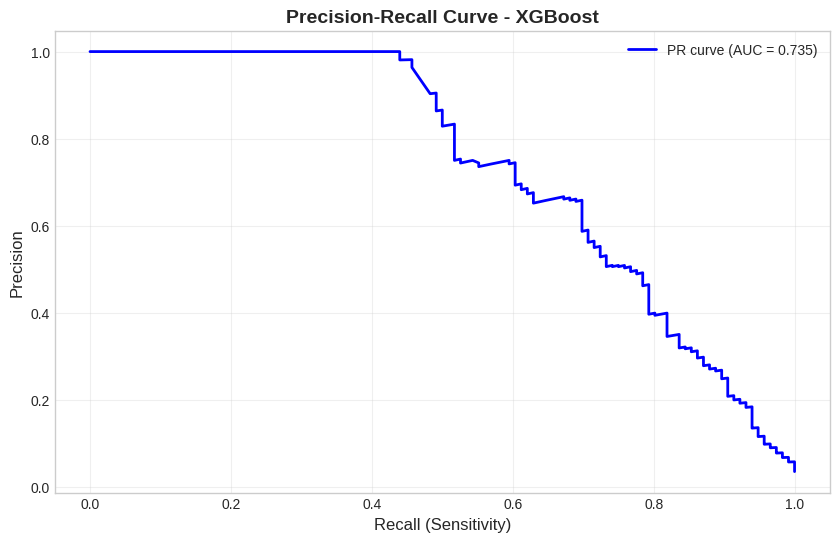

### 🌟 Топ-10 важных признаков (XGBoost):

,Признак,Важность
151,UA_нестабильная_стенокардия,0.118297
50,Нейтрофилы_абсолютное_значение,0.087084
75,SIRI_NxM_/L,0.030584
15,Стентирование_в_анамнезе,0.030373
115,Креатинин,0.030061
133,РЕКОРД,0.028104
170,LACTartMax_b,0.027479
37,СДЛА,0.023955
131,ФВ_lt_40,0.020546
134,PAMI,0.016357


In [ ]:
model_trained, results = train_and_evaluate_model(
    xgb_model, "XGBoost", X_train, y_train, X_val, y_val, X_test, y_test, ""
)
models_results["XGBoost"] = {"model": model_trained, "results": results}

### 🚀 Обучение LightGBM...

✅ **LightGBM обучена за 0.87 секунд**

### 📊 Результаты LightGBM:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,1.000000,0.713415,0.832740,0.999443,0.984513
Validation,0.685185,0.532374,0.599190,0.938592,0.666136
Test,0.706897,0.543046,0.614232,0.964681,0.735610


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 69

- False Negative (пропущенные смерти) ⚠️: 34

- True Positive (правильные предсказания смерти): 82

❌ **КРИТИЧНО:** Модель пропустила 34 смертельных случаев!

⚠️ **Внимание:** 69 ложных тревог могут привести к ненужным вмешательствам

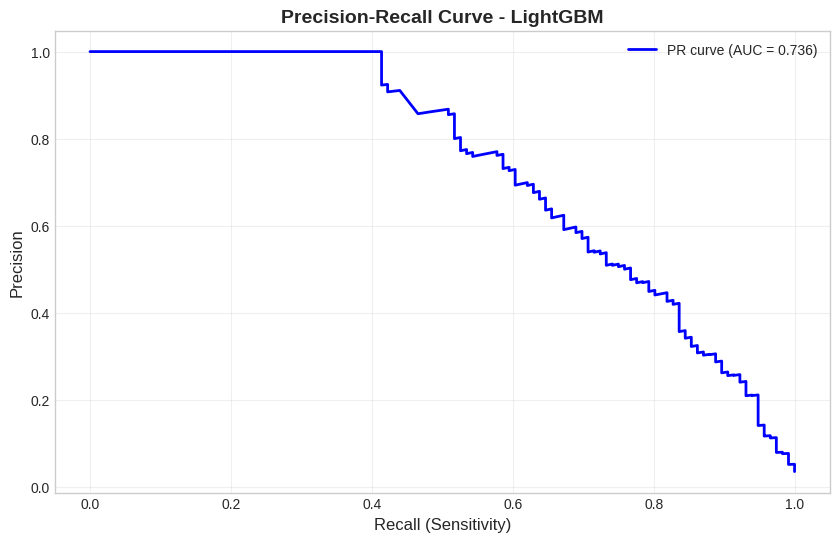

### 🌟 Топ-10 важных признаков (LightGBM):

,Признак,Важность
50,Нейтрофилы_абсолютное_значение,105
115,Креатинин,97
113,ЧСС_b,82
37,СДЛА,51
131,ФВ_lt_40,50
1,Age,43
170,LACTartMax_b,43
81,Глюкоза_в_мг/дл,40
126,SpO2,38
104,GRACE_Общее,34


In [ ]:
model_trained, results = train_and_evaluate_model(
    lgb_model, "LightGBM", X_train, y_train, X_val, y_val, X_test, y_test, ""
)
models_results["LightGBM"] = {"model": model_trained, "results": results}

In [ ]:
test_table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16613 entries, 47 to 17429
Columns: 196 entries, Код пациента to BNP (b)
dtypes: category(67), float64(125), object(4)
memory usage: 17.6+ MB


### 🚀 Обучение CatBoost...

✅ **CatBoost обучена за 1.16 секунд**

### 📊 Результаты CatBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,0.943020,0.330339,0.489283,0.981485,0.740093
Validation,0.787037,0.269841,0.401891,0.933501,0.619057
Test,0.862069,0.316456,0.462963,0.961923,0.722274


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 216

- False Negative (пропущенные смерти) ⚠️: 16

- True Positive (правильные предсказания смерти): 100

❌ **КРИТИЧНО:** Модель пропустила 16 смертельных случаев!

⚠️ **Внимание:** 216 ложных тревог могут привести к ненужным вмешательствам

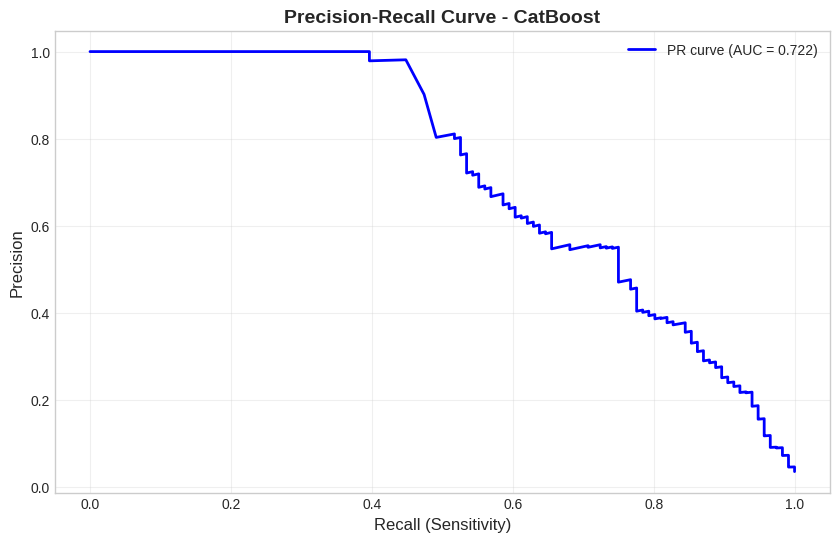

### 🌟 Топ-10 важных признаков (CatBoost):

,Признак,Важность
133,РЕКОРД,8.279431
3,STEMI,5.902268
50,Нейтрофилы_абсолютное_значение,4.426357
152,killip,3.785218
115,Креатинин,3.717093
173,HCO3ArtMin_b,3.634943
53,Эозинофилы_абсолютное_значение,3.555034
113,ЧСС_b,3.394275
33,КСР_ЛЖ,2.836254
13,Инфаркт_миокарда_со_стентированием_в_анамнезе,2.809520


In [ ]:
model_trained, results = train_and_evaluate_model(
    cat_model,
    "CatBoost",
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    X_clean.select_dtypes(include=["category", "object"]).columns.tolist(),
)
if model_trained is not None:
    models_results["CatBoost"] = {"model": model_trained, "results": results}

-------------------------------

### Делим на STEMI

In [ ]:
test_stemi_yes = test_table[test_table["STEMI"] == "Да"]
test_stemi_no = test_table[test_table["STEMI"] == "Нет"]

In [ ]:
test_stemi_yes["Смерть"] = test_stemi_yes["Смерть"].map({"Да": 1, "Нет": 0})
test_stemi_yes.dropna(subset=["Смерть"], inplace=True)

test_stemi_no["Смерть"] = test_stemi_no["Смерть"].map({"Да": 1, "Нет": 0})
test_stemi_no.dropna(subset=["Смерть"], inplace=True)

In [ ]:
test_stemi_no

,Код пациента,Name,Age,Sex,STEMI,ЧКВ,Вид STEMI,Инфаркт-зависимая артерия,Поражение ствола,Количество пораженных сосудов(Syntax),...,PCO2VenMax (b),ScvO2Min (b),ScvO2Max (b),LactVenMin (b),LactVenMax (b),BEVenMin (b),BEVenMax (b),HCO3VenMin (b),HCO3VenMax (b),BNP (b)
47,17-12105,Бабаев СН,59.0,М,Нет,Да,nan,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,17-17180,Ползиков СВ,58.0,М,Нет,Да,nan,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,15536,Анфёров ЮА,74.0,М,Нет,Да,nan,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,17-20825,Кондрашин АА,31.0,М,Нет,Нет,nan,0,Нет,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
687,14668,Мелещенко АВ,43.0,nan,Нет,Да,nan,ПМЖВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6494,20-16149,Хаченков ВН,66.0,М,Нет,Да,nan,ПКА - Несовадает,Нет,2.0,...,38.4,82.6,82.6,2.9,2.9,-1.6,-1.6,22.8,22.8,NaN
6495,18-11214,Чайка СП,64.0,М,Нет,Да,nan,ПМЖВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6497,19-10494,Шеремета ВА,54.0,М,Нет,Да,nan,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6498,8235,Шибе СИ,55.0,М,Нет,Да,nan,ПКА - Несовадает,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
X = test_stemi_yes.drop(["Смерть"], axis=1)
y = test_stemi_yes["Смерть"]

In [ ]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace("[", "_").replace("]", "_").replace("<", "_lt_")
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace(">", "_gt_").replace(" ", "_").replace(":", "_")
        clean_col = clean_col.replace("(", "_").replace(")", "_").replace(",", "_")
        clean_col = clean_col.replace("{", "_").replace("}", "_").replace("|", "_")
        # Удаляем последовательные подчеркивания
        clean_col = "_".join(filter(None, clean_col.split("_")))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip("_")
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = "f_" + clean_col
        new_columns.append(clean_col)

    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean


# Применяем к вашим данным
X_clean = clean_column_names(X)

In [ ]:
object_cols = X_clean.select_dtypes(include=["object"]).columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in object_cols:
    le = LabelEncoder()
    # Обучаем encoder на объединённых данных, чтобы избежать ошибок с новыми категориями в тесте
    combined = pd.concat([X_clean[col], X_clean[col]], axis=0).astype(str)
    le.fit(combined)
    X_clean[col] = le.transform(X_clean[col].astype(str))

In [ ]:
X_clean.drop(["Код_пациента"], axis=1, inplace=True)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# ШАГ 1: отделяем TEST (20% групп)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.08, random_state=42)
train_val_idx, test_idx = next(gss1.split(X_clean, y, test_stemi_yes["Name"]))

# Получаем индексы для train+val и test
X_train_val = X_clean.iloc[train_val_idx]
y_train_val = y.iloc[train_val_idx]
groups_train_val = test_stemi_yes["Name"].iloc[train_val_idx]

# ШАГ 2: из оставшихся групп отделяем VALIDATION
# Доля валидации от ОСТАВШИХСЯ данных: val_frac = val_size / (train_size+val_size)
# Допустим, мы хотим train=0.6, val=0.2, test=0.2 от исходного датасета.
# Тогда val_frac = 0.2 / (0.6+0.2) = 0.25
val_frac = 0.08  # 25% от train_val
gss2 = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=42)
train_idx, val_idx = next(gss2.split(X_train_val, y_train_val, groups_train_val))

# Теперь train_idx, val_idx, test_idx – это индексы внутри ИСХОДНОГО датафрейма?
# Нет, нужно быть внимательным: gss2 вернул индексы относительно X_train_val, а не исходного df.
# Чтобы получить окончательные индексы в исходном df, делаем так:
train_idx_original = train_val_idx[train_idx]
val_idx_original = train_val_idx[val_idx]

# Теперь можно сформировать финальные выборки
X_train = X_clean.iloc[train_idx_original]
X_val = X_clean.iloc[val_idx_original]
X_test = X_clean.iloc[test_idx]

y_train = y.iloc[train_idx_original]
y_val = y.iloc[val_idx_original]
y_test = y.iloc[test_idx]

# Проверяем, что группы не пересекаются
print("Пациенты в train:", set(test_stemi_yes.iloc[train_idx_original]["Name"]))
print("Пациенты в val:  ", set(test_stemi_yes.iloc[val_idx_original]["Name"]))
print("Пациенты в test: ", set(test_stemi_yes.iloc[test_idx]["Name"]))

Пациенты в train: {'Шабалина СВ', 'Аксенов ВВ', 'Шашкова ЕЛ', 'Иванова ВП', 'Кудрин АА', 'Шаповалова ЕД', 'Грищенко АГ', 'Винарцев ВВ', 'Тулупов ВВ', 'Рихтер МП', 'Ващенко НГ', 'Зарубин ИЗ', 'Воротеляк АА', 'Филимонова РА', 'Костенко АИ', 'Жаботаев АС', 'Чепсакова СА', 'Давыдов ВШ', 'Тихомиров ВА', 'Кирика КП', 'Фомина ЛК', 'Суржик ОИ', 'Тыжук ВА', 'Заднепренко ВИ', 'Кушнер ГГ', 'Лысенко ТВ', 'Марыгина СВ', 'Чепа ЕЕ', 'Кривоносов АМ', 'Макеев ЕВ', 'Старовойтов АА', 'Луканин ВВ', 'Прокопец АА', 'Радюкевич АГ', 'Лозяников АГ', 'Макеева НД', 'Семенов ВА', 'Переведенцев АИ', 'Жога ВА', 'Дудова ЗП', 'Успаленко ВА', 'Шелег АА', 'Балюк КЛ', 'Палей ВВ', 'Братченко НВ', 'Май ЕВ', 'Тихоненко СВ', 'Гресько ВЛ', 'Пасошников ВН', 'Жильцов МС', 'Грицай ГО', 'Погосян РФ', 'Онищук СС', 'Полозов НП', 'Сеславский ВИ', 'Березина НП', 'Махраков ММ', 'Ершов ГА', 'Виноградов ВА', 'Терновская СА', 'Данильченко ВФ', 'Пак Н', 'Гаврилюк ИИ', 'Каздровская МВ', 'Гудименко ГА', 'Смиянов ВН', 'Денисенко АА', 'Калин

In [ ]:
sum(y_train), sum(y_val), sum(y_test)

(327.0, 31.0, 38.0)

In [ ]:
scale_pos_weight = len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

In [ ]:
scale_pos_weight

13.807339449541285

In [ ]:
def train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    """
    Обучает модель и оценивает её качество с фокусом на медицинские метрики
    Согласно официальной документации библиотек
    """
    start_time = time.time()

    display(Markdown(f"### 🚀 Обучение {model_name}..."))

    try:
        # Обучение модели в зависимости от типа (согласно документации)
        if model_name == "XGBoost":
            # Согласно документации XGBoost: https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        elif model_name == "LightGBM":
            # Согласно документации LightGBM: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
            model.fit(
                X_train,
                y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lightgbm.early_stopping(stopping_rounds=50, verbose=False)],  # Корректный синтаксис
            )

        elif model_name == "CatBoost":
            # Согласно документации CatBoost: https://catboost.ai/en/docs/concepts/python-quickstart
            model.fit(
                X_train,
                y_train,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                verbose=False,
                cat_features=cat_features,
            )

        train_time = time.time() - start_time
        display(Markdown(f"✅ **{model_name} обучена за {train_time:.2f} секунд**"))

        # Предсказания
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        y_pred_test = model.predict(X_test)

        # Вероятности для класса 1 (смерть)
        if hasattr(model, "predict_proba"):
            y_proba_train = model.predict_proba(X_train)[:, 1]
            y_proba_val = model.predict_proba(X_val)[:, 1]
            y_proba_test = model.predict_proba(X_test)[:, 1]
        else:
            # Для моделей без predict_proba
            y_proba_train = model.decision_function(X_train)
            y_proba_val = model.decision_function(X_val)
            y_proba_test = model.decision_function(X_test)

        # Оценка качества
        results = {}

        for dataset_name, y_true, y_pred, y_proba in [
            ("Train", y_train, y_pred_train, y_proba_train),
            ("Validation", y_val, y_pred_val, y_proba_val),
            ("Test", y_test, y_pred_test, y_proba_test),
        ]:
            # Основные метрики
            recall = recall_score(y_true, y_pred)  # Sensitivity - критично в медицине!
            precision = precision_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            roc_auc = roc_auc_score(y_true, y_proba)

            # Precision-Recall AUC (важнее ROC-AUC при дисбалансе)
            precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
            pr_auc = auc(recall_curve, precision_curve)

            results[dataset_name] = {
                "Recall (Sensitivity)": recall,
                "Precision": precision,
                "F1-score": f1,
                "ROC-AUC": roc_auc,
                "PR-AUC": pr_auc,
            }

        # Отображение результатов
        display(Markdown(f"### 📊 Результаты {model_name}:"))

        # Таблица метрик
        metrics_df = pd.DataFrame(results).T
        display(metrics_df.style.background_gradient(cmap="Blues", subset=["Recall (Sensitivity)", "PR-AUC"]))

        # Важно: анализ ошибок для медицины
        display(Markdown("### ⚠️ Анализ ошибок (крайне важно для медицины):"))

        # Confusion matrix для тестового набора
        cm = confusion_matrix(y_test, y_pred_test)
        tn, fp, fn, tp = cm.ravel()

        display(Markdown(f"**Confusion Matrix (Test set):**"))
        display(Markdown(f"- True Negative (правильные выжившие): {tn}"))
        display(Markdown(f"- False Positive (ложные тревоги): {fp}"))
        display(Markdown(f"- False Negative (пропущенные смерти) ⚠️: {fn}"))
        display(Markdown(f"- True Positive (правильные предсказания смерти): {tp}"))

        # Критический анализ
        if fn > 0:
            display(Markdown(f"❌ **КРИТИЧНО:** Модель пропустила {fn} смертельных случаев!"))
        if fp > 0:
            display(Markdown(f"⚠️ **Внимание:** {fp} ложных тревог могут привести к ненужным вмешательствам"))

        # Визуализация Precision-Recall кривой (важнее ROC при дисбалансе)
        plt.figure(figsize=(10, 6))
        plt.plot(recall_curve, precision_curve, "b-", linewidth=2, label=f"PR curve (AUC = {pr_auc:.3f})")
        plt.xlabel("Recall (Sensitivity)", fontsize=12)
        plt.ylabel("Precision", fontsize=12)
        plt.title(f"Precision-Recall Curve - {model_name}", fontsize=14, fontweight="bold")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

        # Важность признаков
        if hasattr(model, "feature_importances_"):
            feature_importance = pd.DataFrame(
                {"Признак": X_train.columns, "Важность": model.feature_importances_}
            ).sort_values("Важность", ascending=False)

            display(Markdown(f"### 🌟 Топ-10 важных признаков ({model_name}):"))
            display(feature_importance.head(10).style.background_gradient(cmap="Greens"))

        return model, results

    except Exception as e:
        display(Markdown(f"❌ **Ошибка при обучении {model_name}:** {e}"))
        return None, None

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    # missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric="logloss",  # для бинарной классификации
    tree_method="auto",  # автоматический выбор метода обучения
    enable_categorical=True,
)

# LightGBM - автоматическая обработка пропусков
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    early_stopping_rounds=50,  # задается при инициализации
)

# CatBoost - отличная обработка пропусков
cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric="Logloss",
    early_stopping_rounds=50,  # задается при инициализации
)

In [ ]:
models_results = {}

### 🚀 Обучение XGBoost...

✅ **XGBoost обучена за 0.63 секунд**

### 📊 Результаты XGBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,1.000000,0.958944,0.979042,0.999995,0.999935
Validation,0.903226,0.756757,0.823529,0.977642,0.923200
Test,0.815789,0.775000,0.794872,0.978922,0.897264


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 9

- False Negative (пропущенные смерти) ⚠️: 7

- True Positive (правильные предсказания смерти): 31

❌ **КРИТИЧНО:** Модель пропустила 7 смертельных случаев!

⚠️ **Внимание:** 9 ложных тревог могут привести к ненужным вмешательствам

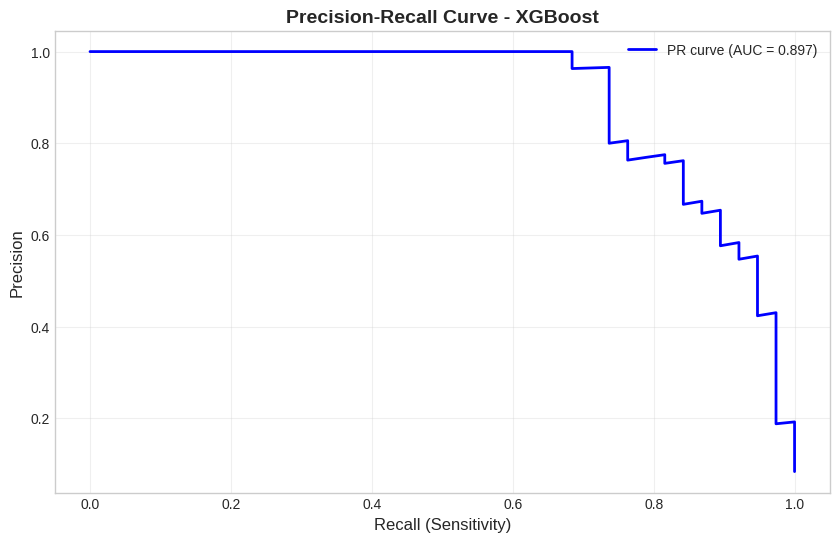

### 🌟 Топ-10 важных признаков (XGBoost):

,Признак,Важность
50,Нейтрофилы_абсолютное_значение,0.149440
37,СДЛА,0.044396
132,CADILLAC,0.025398
152,killip,0.025088
133,РЕКОРД,0.024420
101,МНО_b,0.020831
173,HCO3ArtMin_b,0.020757
157,Натрий_Na,0.020558
143,GRACE_Высокий_риск,0.019207
131,ФВ_lt_40,0.017905


In [ ]:
model_trained, results = train_and_evaluate_model(
    xgb_model, "XGBoost", X_train, y_train, X_val, y_val, X_test, y_test, []
)
models_results["XGBoost"] = {"model": model_trained, "results": results}

### 🚀 Обучение LightGBM...

✅ **LightGBM обучена за 0.61 секунд**

### 📊 Результаты LightGBM:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,1.000000,0.964602,0.981982,0.999999,0.999991
Validation,0.870968,0.729730,0.794118,0.978467,0.916692
Test,0.789474,0.833333,0.810811,0.982582,0.908314


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 6

- False Negative (пропущенные смерти) ⚠️: 8

- True Positive (правильные предсказания смерти): 30

❌ **КРИТИЧНО:** Модель пропустила 8 смертельных случаев!

⚠️ **Внимание:** 6 ложных тревог могут привести к ненужным вмешательствам

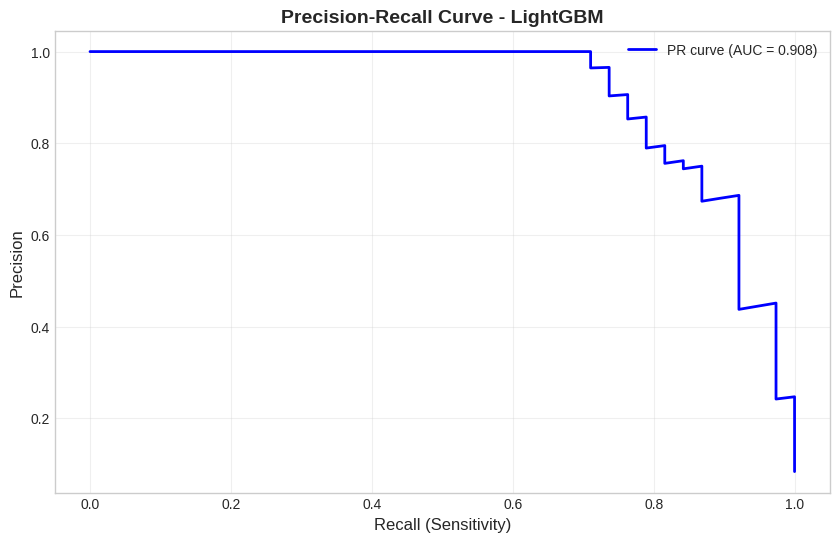

### 🌟 Топ-10 важных признаков (LightGBM):

,Признак,Важность
50,Нейтрофилы_абсолютное_значение,104
124,Стенокардия_в_диагнозе_при_поступлении,65
115,Креатинин,64
116,СКФ,63
37,СДЛА,61
81,Глюкоза_в_мг/дл,55
131,ФВ_lt_40,52
111,Систолическое_АД_b,52
113,ЧСС_b,48
67,PLR_тромбоциты/лимфоциты_абс_61-239,43


In [ ]:
model_trained, results = train_and_evaluate_model(
    lgb_model, "LightGBM", X_train, y_train, X_val, y_val, X_test, y_test, []
)
models_results["LightGBM"] = {"model": model_trained, "results": results}

### 🚀 Обучение CatBoost...

✅ **CatBoost обучена за 1.15 секунд**

### 📊 Результаты CatBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,0.963303,0.593220,0.734266,0.990849,0.915006
Validation,0.903226,0.595745,0.717949,0.977230,0.888716
Test,0.868421,0.550000,0.673469,0.967878,0.829023


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 27

- False Negative (пропущенные смерти) ⚠️: 5

- True Positive (правильные предсказания смерти): 33

❌ **КРИТИЧНО:** Модель пропустила 5 смертельных случаев!

⚠️ **Внимание:** 27 ложных тревог могут привести к ненужным вмешательствам

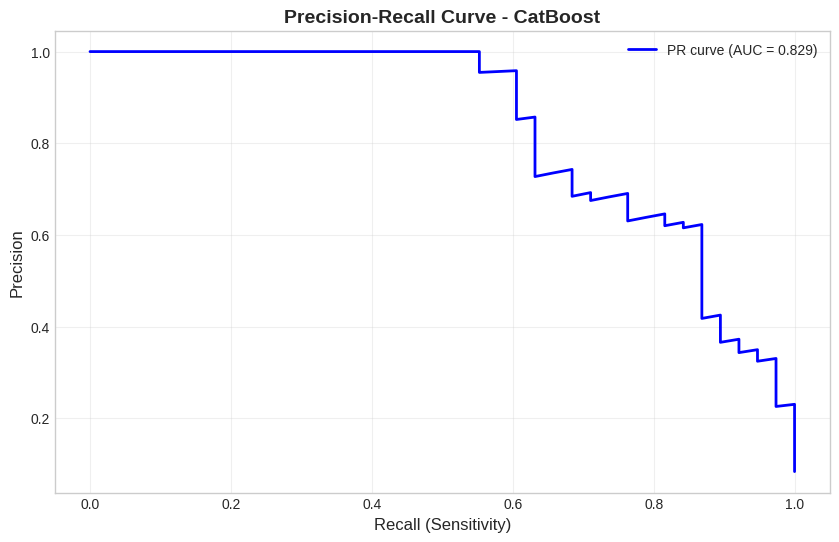

### 🌟 Топ-10 важных признаков (CatBoost):

,Признак,Важность
53,Эозинофилы_абсолютное_значение,5.098458
152,killip,4.767352
33,КСР_ЛЖ,4.692264
138,CADILLAC_Высокий_риск,4.392662
79,RLR_RDW/_lymph_abs,3.857092
50,Нейтрофилы_абсолютное_значение,3.847238
26,Стенокардия_ИБ,3.638733
131,ФВ_lt_40,3.617630
157,Натрий_Na,3.289415
124,Стенокардия_в_диагнозе_при_поступлении,3.137912


In [ ]:
model_trained, results = train_and_evaluate_model(
    cat_model,
    "CatBoost",
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    X_clean.select_dtypes(include=["category", "object"]).columns.tolist(),
)
if model_trained is not None:
    models_results["CatBoost"] = {"model": model_trained, "results": results}

In [ ]:
comparison_data = []

for model_name, data in models_results.items():
    results = data["results"]
    test_metrics = results["Test"]

    comparison_data.append(
        {
            "Модель": model_name,
            "Recall (Sensitivity)": test_metrics["Recall (Sensitivity)"],
            "Precision": test_metrics["Precision"],
            "F1-score": test_metrics["F1-score"],
            "PR-AUC": test_metrics["PR-AUC"],
            "ROC-AUC": test_metrics["ROC-AUC"],
        }
    )

comparison_df = pd.DataFrame(comparison_data).sort_values("Recall (Sensitivity)", ascending=False)

display(Markdown("### 🏆 Сравнение моделей на тестовом наборе:"))
display(
    comparison_df.style.background_gradient(cmap="Blues", subset=["Recall (Sensitivity)", "PR-AUC"]).format(
        {
            "Recall (Sensitivity)": "{:.3f}",
            "Precision": "{:.3f}",
            "F1-score": "{:.3f}",
            "PR-AUC": "{:.3f}",
            "ROC-AUC": "{:.3f}",
        }
    )
)

# Рекомендация по выбору модели
best_recall_model = comparison_df.iloc[0]["Модель"]
best_pr_auc_model = comparison_df.sort_values("PR-AUC", ascending=False).iloc[0]["Модель"]

display(Markdown("## 🎯 Рекомендации по выбору модели:"))

if best_recall_model == best_pr_auc_model:
    display(Markdown(f"### ✅ **{best_recall_model} показала лучшие результаты по всем ключевым метрикам**"))
else:
    display(Markdown(f"### 🔍 **Разные модели лидируют по разным метрикам:**"))
    display(Markdown(f"- **Лучший Recall (чувствительность):** {best_recall_model} - приоритет для медицины!"))
    display(Markdown(f"- **Лучший PR-AUC:** {best_pr_auc_model} - баланс precision/recall"))

### 🏆 Сравнение моделей на тестовом наборе:

,Модель,Recall (Sensitivity),Precision,F1-score,PR-AUC,ROC-AUC
2,CatBoost,0.868,0.550,0.673,0.829,0.968
0,XGBoost,0.816,0.775,0.795,0.897,0.979
1,LightGBM,0.789,0.833,0.811,0.908,0.983


## 🎯 Рекомендации по выбору модели:

### 🔍 **Разные модели лидируют по разным метрикам:**

- **Лучший Recall (чувствительность):** CatBoost - приоритет для медицины!

- **Лучший PR-AUC:** LightGBM - баланс precision/recall

In [ ]:
list(models_results.keys())

['XGBoost', 'LightGBM', 'CatBoost']

## 📊 Диагностика текущих результатов

### Confusion Matrix для LightGBM:

,Predicted 0,Predicted 1
Actual 0 (Выжил),411,6
Actual 1 (Умер),8,30


### Критические метрики:

- **Recall (Sensitivity) для смерти:** 0.789

- **Количество пропущенных смертей (FN):** 8 из 38

- **Precision для смерти:** 0.833

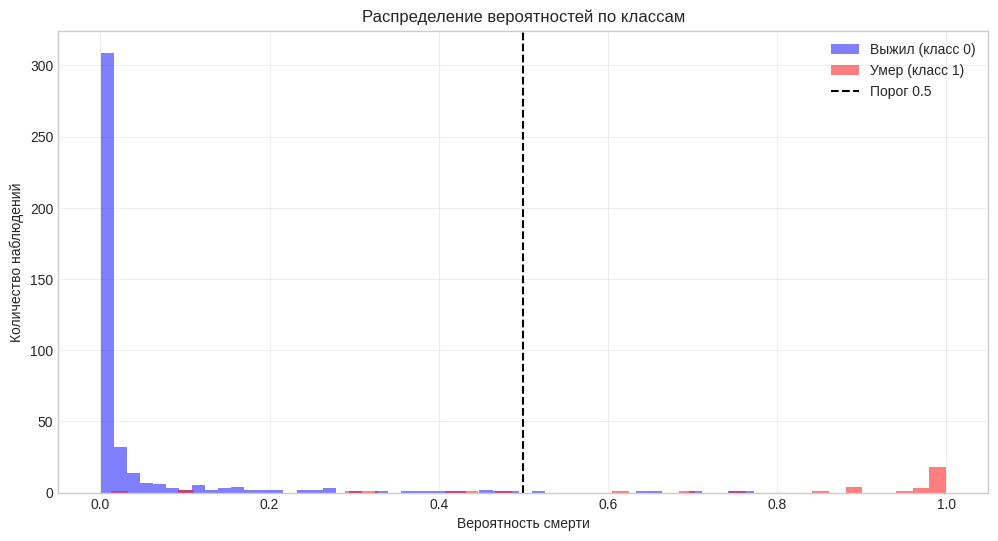

In [ ]:
# %% [markdown]
# ## 🔍 Шаг 1: Диагностика текущего состояния моделей

# %%
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Анализ предсказаний лучшей модели
# best_model_name = list(models_results.keys())[0]  # или выберите лучшую по Recall
best_model_name = "LightGBM"
best_model = models_results[best_model_name]["model"]

# Получаем предсказания
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

display(Markdown("## 📊 Диагностика текущих результатов"))
display(Markdown(f"### Confusion Matrix для {best_model_name}:"))
cm_df = pd.DataFrame(cm, index=["Actual 0 (Выжил)", "Actual 1 (Умер)"], columns=["Predicted 0", "Predicted 1"])
display(cm_df)

display(Markdown(f"### Критические метрики:"))
display(Markdown(f"- **Recall (Sensitivity) для смерти:** {tp / (tp + fn):.3f}"))
display(Markdown(f"- **Количество пропущенных смертей (FN):** {fn} из {tp + fn}"))
display(Markdown(f"- **Precision для смерти:** {tp / (tp + fp):.3f}"))

# Распределение вероятностей
plt.figure(figsize=(12, 6))
plt.hist(y_proba_test[y_test == 0], bins=50, alpha=0.5, label="Выжил (класс 0)", color="blue")
plt.hist(y_proba_test[y_test == 1], bins=50, alpha=0.5, label="Умер (класс 1)", color="red")
plt.axvline(x=0.5, color="k", linestyle="--", label="Порог 0.5")
plt.xlabel("Вероятность смерти")
plt.ylabel("Количество наблюдений")
plt.title("Распределение вероятностей по классам")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Проверка: есть ли вообще предсказания класса 1?
if tp + fp == 0:
    display(Markdown("❌ **КРИТИЧЕСКАЯ ПРОБЛЕМА:** Модель вообще не предсказывает класс 1 (смерть)!"))
    display(Markdown("Это означает, что модель считает всех пациентов выжившими."))

### Optuna

In [ ]:
import pandas as pd
import numpy as np
import optuna
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
spw = scale_pos_weight

In [ ]:
def optimize_model(model_name, trial):
    """Единая objective-функция для Optuna (исправлено под API >= 1.6)"""
    if model_name == "XGBoost":
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.5, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 80),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 70),
            "subsample": trial.suggest_float("subsample", 0.1, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 1.0),
            "gamma": trial.suggest_float("gamma", 0.0, 10.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 30.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 30.0, log=True),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", spw * 0.5, spw * 2.0),
            "tree_method": "hist",
            "eval_metric": "logloss",
            "random_state": 42,
            "verbosity": 0,
            "enable_categorical": True,
            "callbacks": [xgb.callback.EarlyStopping(rounds=50, save_best=True)],
        }

        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    elif model_name == "LightGBM":
        max_depth = trial.suggest_int("max_depth", 3, 10)

        # Безопасная динамическая граница: не больше 2^depth и не больше практического потолка
        max_leaves = max(15, min(2**max_depth, 255))  # 255 покрывает 99% задач, >512 почти всегда вредит
        num_leaves = trial.suggest_int("num_leaves", 15, max_leaves)

        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.5, log=True),
            "num_leaves": num_leaves,
            "max_depth": max_depth,
            "min_child_samples": trial.suggest_int("min_child_samples", 1, 300),
            "subsample": trial.suggest_float("subsample", 0.1, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 30.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 30.0, log=True),
            "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced", {0: 1, 1: spw}]),
            "random_state": 42,
            "verbose": -1,
        }
        model = LGBMClassifier(**params)
        # ✅ LightGBM принимает callbacks в fit()
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
        )

    elif model_name == "CatBoost":
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.5, log=True),
            "depth": trial.suggest_int("depth", 1, 100),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
            "subsample": trial.suggest_float("subsample", 0.1, 1.0),
            "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.1, 1.0),
            "border_count": trial.suggest_int("border_count", 32, 512),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "random_strength": trial.suggest_float("random_strength", 0.0, 50.0),
            "class_weights": trial.suggest_categorical("class_weights", [None, [1, spw]]),
            "boosting_type": "Ordered",
            "eval_metric": "Logloss",
            "random_state": 42,
            "verbose": False,
        }
        model = CatBoostClassifier(**params)
        # ✅ CatBoost использует early_stopping_rounds в fit()
        model.fit(
            X_train,
            y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            use_best_model=True,
            verbose=False,
            cat_features=X_train.select_dtypes(include=["category"]).columns.tolist(),
        )

    # # Метрика оптимизации: PR-AUC на валидации
    # proba = model.predict_proba(X_val)[:, 1]
    # prec, rec, _ = precision_recall_curve(y_val, proba)
    # return auc(rec, prec)


import optuna
import optuna.visualization as opt_vis

best_params = {}
studies = {}  # ← сохраняем study для графиков

for name in ["XGBoost", "LightGBM", "CatBoost"]:
    print(f"\n🔍 Тюнинг {name}...")
    study = optuna.create_study(direction="maximize", study_name=f"{name}_study")
    study.optimize(lambda trial: optimize_model(name, trial), n_trials=500, show_progress_bar=True)

    best_params[name] = study.best_params
    studies[name] = study  # ← сохраняем
    print(f"✅ Best PR-AUC: {study.best_value:.4f}")


🔍 Тюнинг XGBoost...


  0%|          | 0/500 [00:00<?, ?it/s]

✅ Best PR-AUC: 0.9554

🔍 Тюнинг LightGBM...


  0%|          | 0/500 [00:00<?, ?it/s]

✅ Best PR-AUC: 0.9509

🔍 Тюнинг CatBoost...


  0%|          | 0/500 [00:00<?, ?it/s]

[W 2026-04-28 01:57:38,335] Trial 0 failed with parameters: {'learning_rate': 0.005024858644579256, 'depth': 58, 'l2_leaf_reg': 8.373383053106956, 'min_data_in_leaf': 89, 'subsample': 0.5292492639690057, 'colsample_bylevel': 0.8569803190638753, 'border_count': 498, 'bagging_temperature': 0.11611972067394938, 'random_strength': 48.63685324257157, 'class_weights': None} because of the following error: CatBoostError('catboost/private/libs/options/oblivious_tree_options.cpp:128: Maximum tree depth is 16').
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_200/1993981296.py", line 99, in <lambda>
    study.optimize(lambda trial: optimize_model(name, trial), n_trials=500, show_progress_bar=True)
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_200/1993981296.py", line 74, in optimize_

CatBoostError: catboost/private/libs/options/oblivious_tree_options.cpp:128: Maximum tree depth is 16

In [ ]:
print(best_params)

{'XGBoost': {'learning_rate': 0.3705492544881076, 'max_depth': 74, 'min_child_weight': 15, 'subsample': 0.8745297951606058, 'colsample_bytree': 0.4954110056842209, 'gamma': 5.233186685488018, 'reg_alpha': 0.0005757915861725465, 'reg_lambda': 4.198614550306633, 'scale_pos_weight': 24.40033721777531}, 'LightGBM': {'max_depth': 8, 'num_leaves': 220, 'learning_rate': 0.30906593527878456, 'min_child_samples': 69, 'subsample': 0.8701085058859857, 'colsample_bytree': 0.4868258750883674, 'reg_alpha': 0.023127138648795138, 'reg_lambda': 0.06691267437317566, 'min_split_gain': 0.1116982770332515, 'class_weight': None}}


In [ ]:
for name, study in studies.items():
    print(f"\n📈 Интерактивные графики Optuna для {name}:")

    # 1. История оптимизации
    fig1 = opt_vis.plot_optimization_history(study)
    fig1.update_layout(title=f"Optimization History | {name}", height=400)
    fig1.show()

    # 2. Важность гиперпараметров (какие параметры сильнее всего влияют на метрику)
    if len(study.trials) > 2:
        fig2 = opt_vis.plot_param_importances(study)
        fig2.update_layout(title=f"Parameter Importances | {name}", height=400)
        fig2.show()

    # 3. Параллельные координаты (визуализация многомерного поиска)
    fig3 = opt_vis.plot_parallel_coordinate(study)
    fig3.update_layout(title=f"Parallel Coordinate | {name}", height=500)
    fig3.show()

    # 4. Slice plot (влияние каждого параметра на целевую метрику)
    fig4 = opt_vis.plot_slice(study)
    fig4.update_layout(title=f"Slice Plot | {name}", height=450)
    fig4.show()

    # 5. Contour plot (взаимодействие двух самых важных параметров)
    top_params = list(study.best_params.keys())[:2]
    if len(top_params) >= 2:
        fig5 = opt_vis.plot_contour(study, params=top_params)
        fig5.update_layout(title=f"Contour ({top_params[0]} vs {top_params[1]}) | {name}", height=450)
        fig5.show()


📈 Интерактивные графики Optuna для XGBoost:



📈 Интерактивные графики Optuna для LightGBM:


TypeError: unhashable type: 'dict'

----------------------

In [ ]:
comparison_data = []

for model_name, data in models_results.items():
    results = data["results"]
    test_metrics = results["Test"]

    comparison_data.append(
        {
            "Модель": model_name,
            "Recall (Sensitivity)": test_metrics["Recall (Sensitivity)"],
            "Precision": test_metrics["Precision"],
            "F1-score": test_metrics["F1-score"],
            "PR-AUC": test_metrics["PR-AUC"],
            "ROC-AUC": test_metrics["ROC-AUC"],
        }
    )

comparison_df = pd.DataFrame(comparison_data).sort_values("Recall (Sensitivity)", ascending=False)

display(Markdown("### 🏆 Сравнение моделей на тестовом наборе:"))
display(
    comparison_df.style.background_gradient(cmap="Blues", subset=["Recall (Sensitivity)", "PR-AUC"]).format(
        {
            "Recall (Sensitivity)": "{:.3f}",
            "Precision": "{:.3f}",
            "F1-score": "{:.3f}",
            "PR-AUC": "{:.3f}",
            "ROC-AUC": "{:.3f}",
        }
    )
)

# Рекомендация по выбору модели
best_recall_model = comparison_df.iloc[0]["Модель"]
best_pr_auc_model = comparison_df.sort_values("PR-AUC", ascending=False).iloc[0]["Модель"]

display(Markdown("## 🎯 Рекомендации по выбору модели:"))

if best_recall_model == best_pr_auc_model:
    display(Markdown(f"### ✅ **{best_recall_model} показала лучшие результаты по всем ключевым метрикам**"))
else:
    display(Markdown(f"### 🔍 **Разные модели лидируют по разным метрикам:**"))
    display(Markdown(f"- **Лучший Recall (чувствительность):** {best_recall_model} - приоритет для медицины!"))
    display(Markdown(f"- **Лучший PR-AUC:** {best_pr_auc_model} - баланс precision/recall"))

### 🏆 Сравнение моделей на тестовом наборе:

,Модель,Recall (Sensitivity),Precision,F1-score,PR-AUC,ROC-AUC
2,CatBoost,0.897,0.362,0.516,0.736,0.975
1,LightGBM,0.784,0.587,0.672,0.760,0.971
0,XGBoost,0.767,0.563,0.650,0.755,0.972


## 🎯 Рекомендации по выбору модели:

### 🔍 **Разные модели лидируют по разным метрикам:**

- **Лучший Recall (чувствительность):** CatBoost - приоритет для медицины!

- **Лучший PR-AUC:** LightGBM - баланс precision/recall

In [ ]:
# Оптимизация порога классификации для максимизации Recall
display(Markdown("## ⚙️ Оптимизация порога классификации"))

best_model_name = best_recall_model  # выбираем модель с лучшим Recall
best_model = models_results[best_model_name]["model"]

# Получаем вероятности на тестовом наборе
if hasattr(best_model, "predict_proba"):
    y_proba_test = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba_test = best_model.decision_function(X_test)

# Находим оптимальный порог для максимизации Recall при приемлемом Precision
thresholds = np.arange(0.1, 1, 0.05)  # низкие пороги для максимизации Recall
best_threshold = 0.5
best_recall = 0
min_acceptable_precision = 0.4  # минимально приемлемая точность

for threshold in thresholds:
    y_pred = (y_proba_test >= threshold).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    if precision >= min_acceptable_precision and recall > best_recall:
        best_recall = recall
        best_threshold = threshold

display(Markdown(f"### 🎯 Оптимальный порог классификации: {best_threshold:.2f}"))
display(Markdown(f"- **Recall при этом пороге:** {best_recall:.3f}"))
display(
    Markdown(
        f"- **Precision при этом пороге:** {precision_score(y_test, (y_proba_test >= best_threshold).astype(int)):.3f}"
    )
)

## ⚙️ Оптимизация порога классификации

### 🎯 Оптимальный порог классификации: 0.60

- **Recall при этом пороге:** 0.793

- **Precision при этом пороге:** 0.426

In [ ]:
# Финальные предсказания с оптимальным порогом
y_pred_optimal = (y_proba_test >= best_threshold).astype(int)
final_recall = recall_score(y_test, y_pred_optimal)
final_precision = precision_score(y_test, y_pred_optimal)
final_f1 = f1_score(y_test, y_pred_optimal)

display(Markdown("### 📊 Финальные метрики с оптимальным порогом:"))
final_metrics_df = pd.DataFrame(
    {
        "Метрика": ["Recall (Sensitivity)", "Precision", "F1-score"],
        "Значение": [final_recall, final_precision, final_f1],
    }
)
display(final_metrics_df.style.background_gradient(cmap="Greens", subset=["Значение"]))

### 📊 Финальные метрики с оптимальным порогом:

,Метрика,Значение
0,Recall (Sensitivity),0.767241
1,Precision,0.514451
2,F1-score,0.615917


## 📊 Диагностика текущих результатов

### Confusion Matrix для CatBoost:

,Predicted 0,Predicted 1
Actual 0 (Выжил),3013,183
Actual 1 (Умер),12,104


### Критические метрики:

- **Recall (Sensitivity) для смерти:** 0.897

- **Количество пропущенных смертей (FN):** 12 из 116

- **Precision для смерти:** 0.362

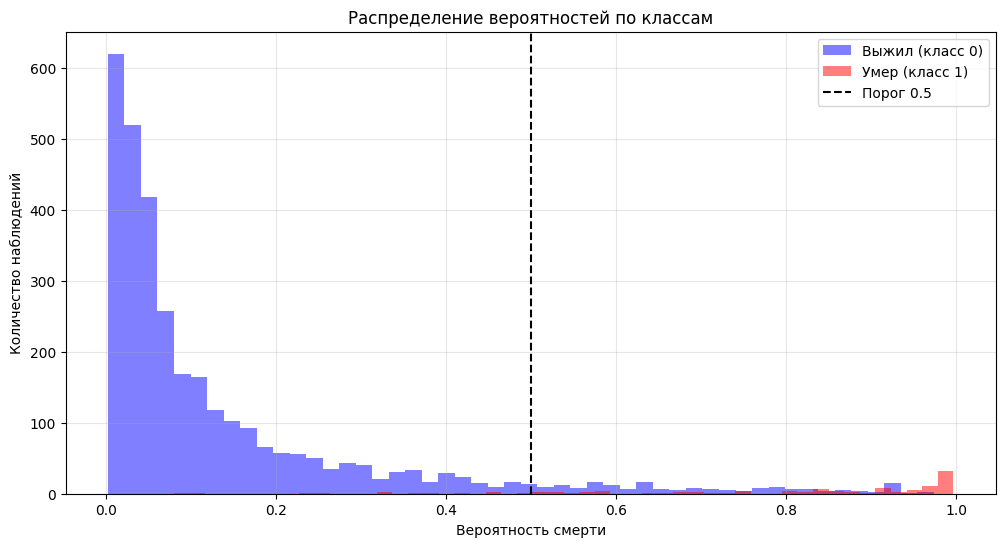

In [ ]:
# %% [markdown]
# ## 🔍 Шаг 1: Диагностика текущего состояния моделей

# %%
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Анализ предсказаний лучшей модели
# best_model_name = list(models_results.keys())[0]  # или выберите лучшую по Recall
best_model = models_results[best_model_name]["model"]

# Получаем предсказания
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

display(Markdown("## 📊 Диагностика текущих результатов"))
display(Markdown(f"### Confusion Matrix для {best_model_name}:"))
cm_df = pd.DataFrame(cm, index=["Actual 0 (Выжил)", "Actual 1 (Умер)"], columns=["Predicted 0", "Predicted 1"])
display(cm_df)

display(Markdown(f"### Критические метрики:"))
display(Markdown(f"- **Recall (Sensitivity) для смерти:** {tp / (tp + fn):.3f}"))
display(Markdown(f"- **Количество пропущенных смертей (FN):** {fn} из {tp + fn}"))
display(Markdown(f"- **Precision для смерти:** {tp / (tp + fp):.3f}"))

# Распределение вероятностей
plt.figure(figsize=(12, 6))
plt.hist(y_proba_test[y_test == 0], bins=50, alpha=0.5, label="Выжил (класс 0)", color="blue")
plt.hist(y_proba_test[y_test == 1], bins=50, alpha=0.5, label="Умер (класс 1)", color="red")
plt.axvline(x=0.5, color="k", linestyle="--", label="Порог 0.5")
plt.xlabel("Вероятность смерти")
plt.ylabel("Количество наблюдений")
plt.title("Распределение вероятностей по классам")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Проверка: есть ли вообще предсказания класса 1?
if tp + fp == 0:
    display(Markdown("❌ **КРИТИЧЕСКАЯ ПРОБЛЕМА:** Модель вообще не предсказывает класс 1 (смерть)!"))
    display(Markdown("Это означает, что модель считает всех пациентов выжившими."))

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint

In [ ]:
best_models = {}

xgb_param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0, 0.5),
    "min_child_weight": randint(1, 10),
    "scale_pos_weight": [scale_pos_weight, scale_pos_weight * 1.5, scale_pos_weight * 2],
}

xgb = XGBClassifier(missing=np.nan, random_state=42, eval_metric="logloss", tree_method="auto")

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="f1",  # Используем F1 как баланс между precision и recall
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

start_time = time.time()
xgb_random.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_train_time = time.time() - start_time

best_xgb = xgb_random.best_estimator_
display(Markdown(f"✅ **XGBoost оптимизирован за {xgb_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{xgb_random.best_params_}\n```"))
display(Markdown(f"**Лучший F1 на кросс-валидации:** {xgb_random.best_score_:.3f}"))

Fitting 3 folds for each of 25 candidates, totalling 75 fits


✅ **XGBoost оптимизирован за 20.24 секунд**

**Лучшие параметры:**

```python
{'colsample_bytree': np.float64(0.7297380084021096), 'gamma': np.float64(0.061043977350336676), 'learning_rate': np.float64(0.11688935142309247), 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 178, 'scale_pos_weight': 27.41025641025641, 'subsample': np.float64(0.8590760482165449)}
```

**Лучший F1 на кросс-валидации:** 0.660

In [ ]:
lgb_param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "num_leaves": randint(15, 60),
    "min_child_samples": randint(5, 30),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "class_weight": [{0: 1, 1: scale_pos_weight}, {0: 1, 1: scale_pos_weight * 1.5}, {0: 1, 1: scale_pos_weight * 2}],
}

lgb = LGBMClassifier(random_state=42, verbose=-1)

lgb_random = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=lgb_param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

start_time = time.time()
lgb_random.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lightgbm.early_stopping(20, verbose=False)])
lgb_train_time = time.time() - start_time

best_lgb = lgb_random.best_estimator_
display(Markdown(f"✅ **LightGBM оптимизирован за {lgb_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{lgb_random.best_params_}\n```"))
display(Markdown(f"**Лучший F1 на кросс-валидации:** {lgb_random.best_score_:.3f}"))

Fitting 3 folds for each of 25 candidates, totalling 75 fits


✅ **LightGBM оптимизирован за 1623.68 секунд**

**Лучшие параметры:**

```python
{'class_weight': {0: 1, 1: 41.11538461538461}, 'colsample_bytree': np.float64(0.6968221086046001), 'learning_rate': np.float64(0.21164066422176356), 'max_depth': 5, 'min_child_samples': 28, 'n_estimators': 172, 'num_leaves': 31, 'subsample': np.float64(0.8912865394447438)}
```

**Лучший F1 на кросс-валидации:** 0.632

In [ ]:
cat_param_dist = {
    "iterations": randint(50, 300),
    "learning_rate": uniform(0.01, 0.3),
    "depth": randint(3, 10),
    "l2_leaf_reg": uniform(1, 10),
    "border_count": randint(32, 128),
    "class_weights": [[1, scale_pos_weight], [1, scale_pos_weight * 1.5], [1, scale_pos_weight * 2]],
}

cat = CatBoostClassifier(random_state=42, verbose=False, eval_metric="F1", early_stopping_rounds=20)

# Для CatBoost используем другой подход из-за специфики API
best_score = -1
best_params = None
best_model = None

display(Markdown("🔍 **Запуск рандомизированного поиска для CatBoost...**"))
start_time = time.time()

for i in range(15):  # 15 итераций вместо 25 из-за скорости CatBoost
    params = {
        "iterations": int(randint(50, 300).rvs()),
        "learning_rate": uniform(0.01, 0.3).rvs(),
        "depth": int(randint(3, 10).rvs()),
        "l2_leaf_reg": uniform(1, 10).rvs(),
        "border_count": int(randint(32, 128).rvs()),
        "class_weights": [1, scale_pos_weight * np.random.choice([1.0, 1.5, 2.0])],
    }

    model = CatBoostClassifier(**params, random_state=42, verbose=False, eval_metric="F1", early_stopping_rounds=20)

    try:
        model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

        # Оценка на validation
        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred)

        if score > best_score:
            best_score = score
            best_params = params
            best_model = model

        if i % 5 == 0:
            display(Markdown(f"Итерация {i + 1}/15: F1 = {score:.3f}"))

    except Exception as e:
        continue

cat_train_time = time.time() - start_time
best_cat = best_model

display(Markdown(f"✅ **CatBoost оптимизирован за {cat_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{best_params}\n```"))
display(Markdown(f"**Лучший F1 на validation:** {best_score:.3f}"))

🔍 **Запуск рандомизированного поиска для CatBoost...**

Итерация 1/15: F1 = 0.388

Итерация 6/15: F1 = 0.382

Итерация 11/15: F1 = 0.443

✅ **CatBoost оптимизирован за 5.72 секунд**

**Лучшие параметры:**

```python
{'iterations': 270, 'learning_rate': np.float64(0.0885920725683974), 'depth': 8, 'l2_leaf_reg': np.float64(8.377077359625186), 'border_count': 101, 'class_weights': [1, np.float64(27.41025641025641)]}
```

**Лучший F1 на validation:** 0.443

In [ ]:
best_models = {"XGBoost": best_xgb, "LightGBM": best_lgb, "CatBoost": best_cat}

results = []

### 📈 Оценка XGBoost

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.689655
1,Precision,0.792079
2,F1-score,0.737327
3,ROC-AUC,0.980015
4,PR-AUC,0.810307


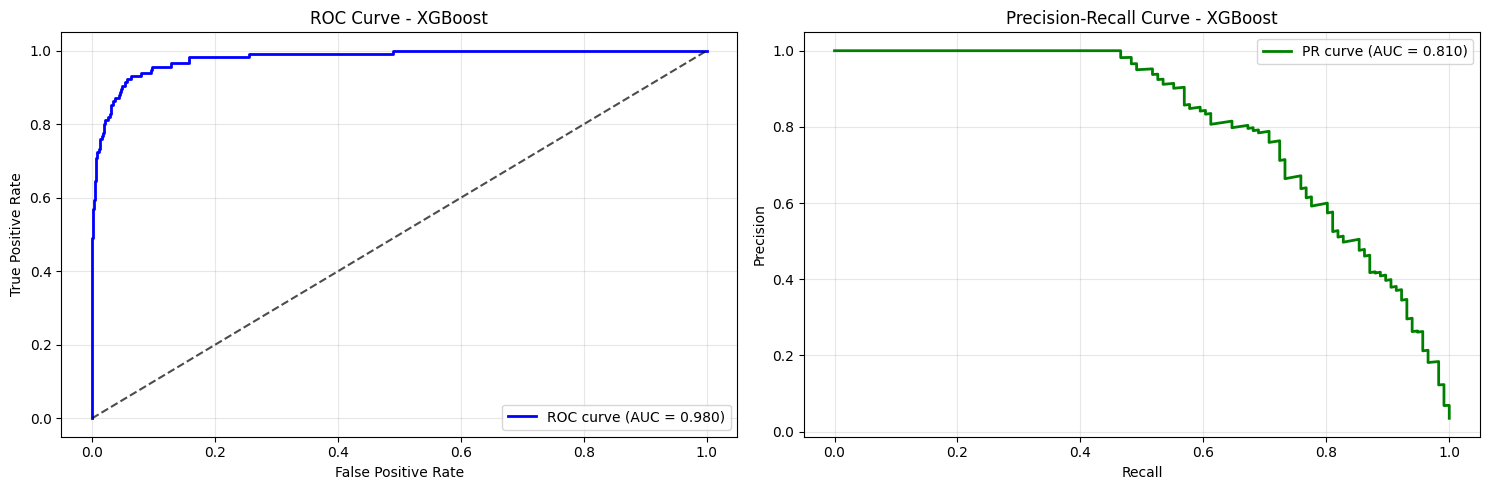

### 📈 Оценка LightGBM

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.741379
1,Precision,0.651515
2,F1-score,0.693548
3,ROC-AUC,0.974777
4,PR-AUC,0.783426


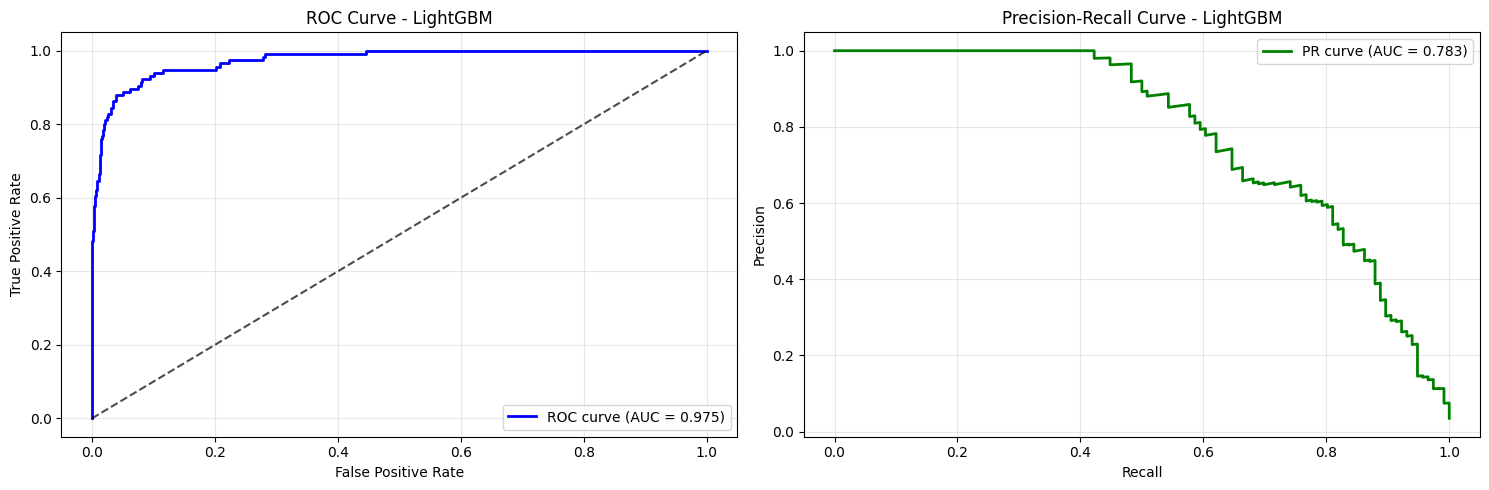

### 📈 Оценка CatBoost

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.844828
1,Precision,0.331081
2,F1-score,0.475728
3,ROC-AUC,0.959725
4,PR-AUC,0.685853


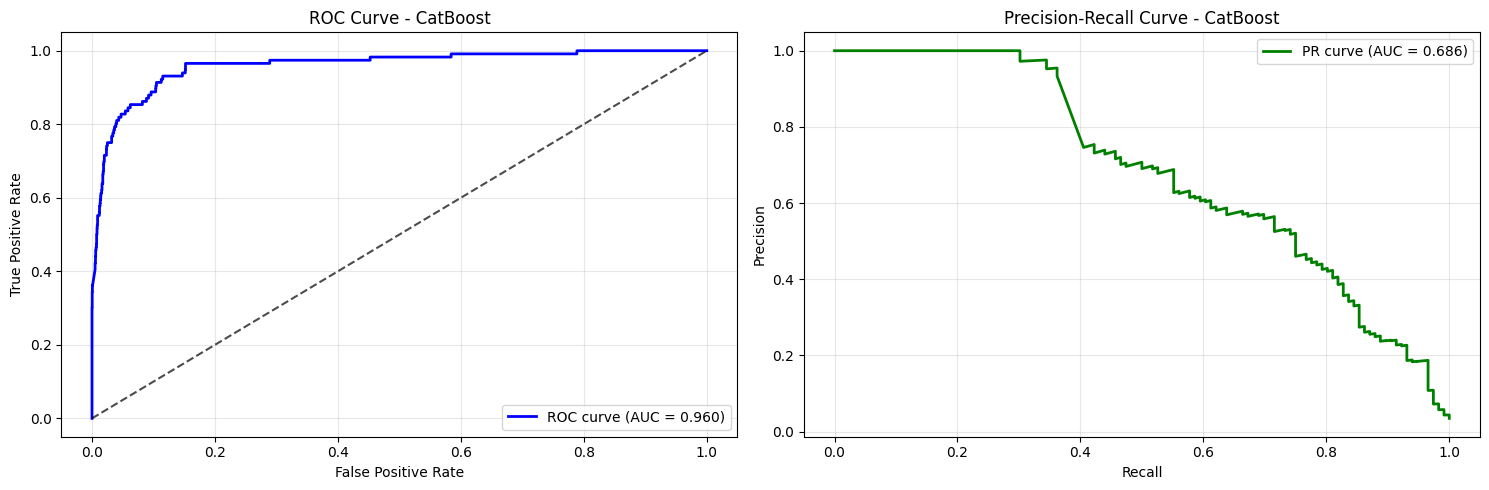

In [ ]:
for name, model in best_models.items():
    display(Markdown(f"### 📈 Оценка {name}"))

    # Предсказания и вероятности
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Метрики
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Precision-Recall AUC
    from sklearn.metrics import precision_recall_curve, auc

    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    results.append(
        {"Модель": name, "Recall": recall, "Precision": precision, "F1-score": f1, "ROC-AUC": roc_auc, "PR-AUC": pr_auc}
    )

    display(Markdown(f"**Метрики на тестовом наборе:**"))
    metrics_df = pd.DataFrame(
        {
            "Метрика": ["Recall", "Precision", "F1-score", "ROC-AUC", "PR-AUC"],
            "Значение": [recall, precision, f1, roc_auc, pr_auc],
        }
    )
    display(metrics_df.style.background_gradient(cmap="Blues", subset=["Значение"]))

    # Визуализация кривых
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # ROC кривая
    from sklearn.metrics import roc_curve

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax1.plot(fpr, tpr, "b-", linewidth=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.7)
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title(f"ROC Curve - {name}")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Precision-Recall кривая
    ax2.plot(recall_curve, precision_curve, "g-", linewidth=2, label=f"PR curve (AUC = {pr_auc:.3f})")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title(f"Precision-Recall Curve - {name}")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
results_df = pd.DataFrame(results)
display(Markdown("## 🏆 Сравнение оптимизированных моделей:"))
display(
    results_df.sort_values("F1-score", ascending=False)
    .style.background_gradient(cmap="Blues", subset=["F1-score", "ROC-AUC"])
    .background_gradient(cmap="Greens", subset=["Recall"])
    .background_gradient(cmap="Oranges", subset=["Precision"])
)

## 🏆 Сравнение оптимизированных моделей:

,Модель,Recall,Precision,F1-score,ROC-AUC,PR-AUC
0,XGBoost,0.689655,0.792079,0.737327,0.980015,0.810307
1,LightGBM,0.741379,0.651515,0.693548,0.974777,0.783426
2,CatBoost,0.844828,0.331081,0.475728,0.959725,0.685853
